I am an NOAA stream gauge.


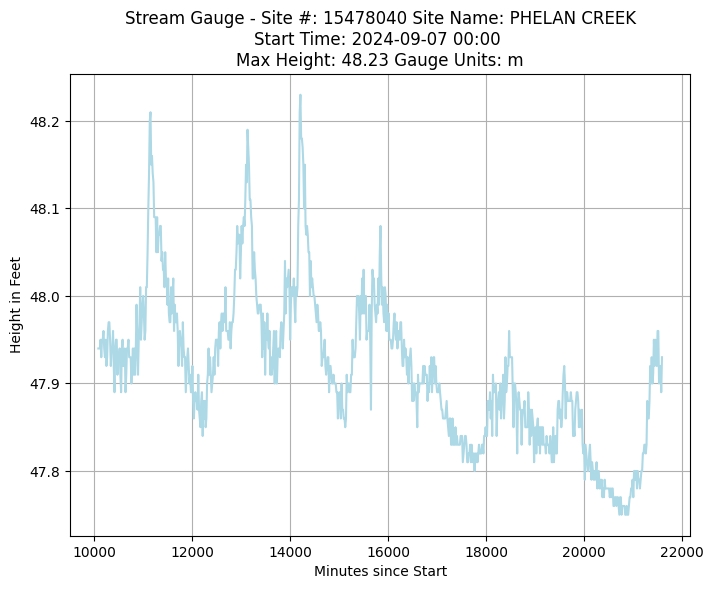

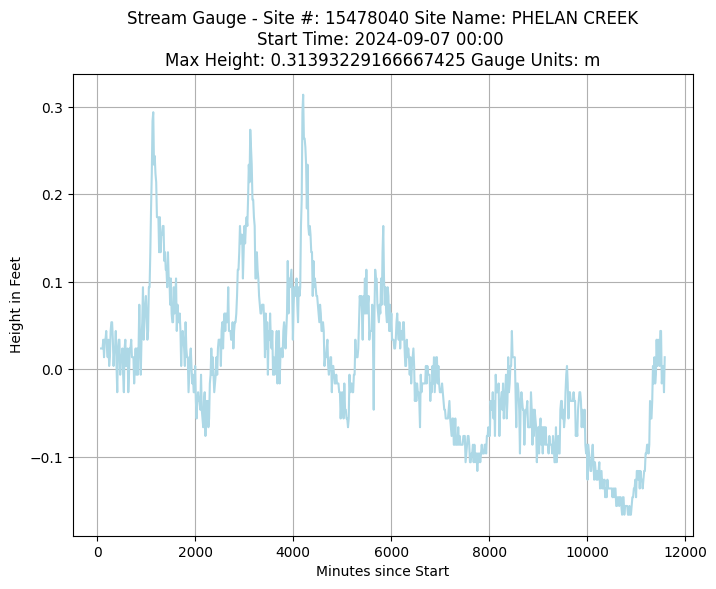

I am an NOAA stream gauge.


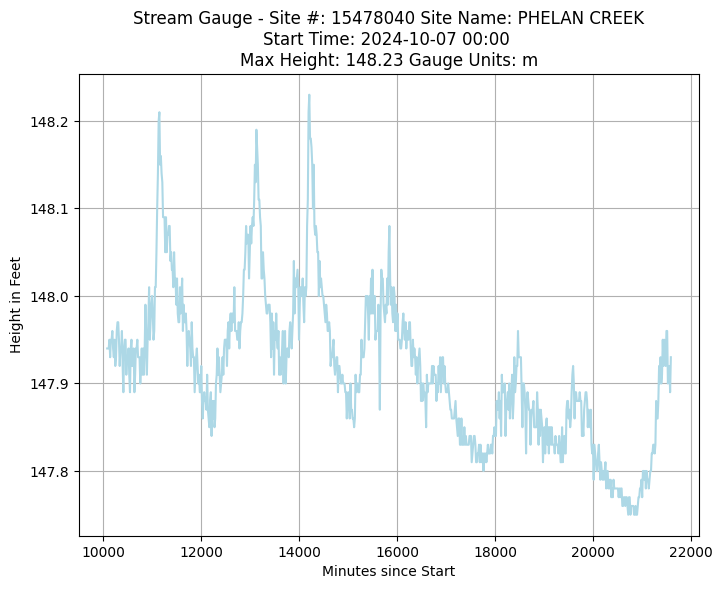

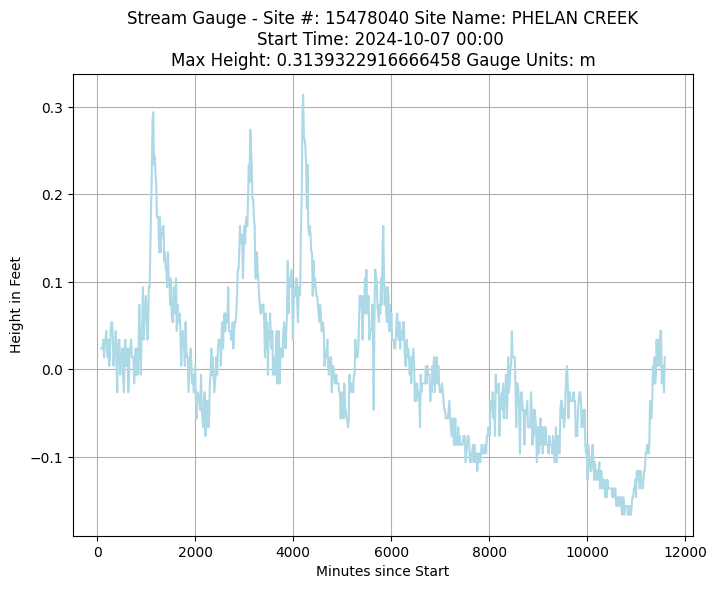

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pdb

class StreamGauge():
    time=[]
    data=[]
    units='ft'
    
    def __init__(self, fid, station_id, station_name, starttime):
        self.fid = fid
        self.station_id = station_id
        self.station_name = station_name
        self.starttime = starttime

    def read_gauge_file(self):
        """
        Read USGS Gauge data and convert date and time to minutes since start
    
        parameters
        fid (str): path to data
    
        returns
        timestamp (list): Minutes since 2024-09-01 00:00
        hgt (np.array): gauge height in ft
        """
        date, time, hgt = np.loadtxt(self.fid, skiprows=28, usecols=[2,3,5], 
                                        dtype=str).T
    
        hgt = hgt.astype(float)
        days = [float(d[-2:]) for d in date]  # get DD from YYYY-MM-DD
        hours = [float(t.split(":")[0]) for t in time]  # get HH from HH:MM
        mins = [float(t.split(":")[1]) for t in time]  # get MM from HH:MM
    
        timestamps = []
        for d, h, m in zip(days, hours, mins):
            timestamp = (d * 24 * 60) + (h * 60) + m
            timestamps.append(timestamp)
        
        self.time = timestamps
        self.data = hgt       


    def plot(self):
        plt.figure(figsize=(8, 6))
        plt.plot(self.time, self.data, 'lightblue')
        plt.title(f"Stream Gauge - Site #: {self.station_id} Site Name: {self.station_name}" 
                  f"\nStart Time: {self.starttime} \nMax Height: {np.max(self.data)} "
                  f"Gauge Units: {self.units}")
        plt.xlabel("Minutes since Start")
        plt.ylabel("Height in Feet")
        plt.grid()
        plt.show()

    def convert(self):
        self.data = self.data * 0.3048

    def demean(self):
        self.data -= np.mean(self.data)

    def shift_time(self, offset):
        self.time = [t + offset for t in self.time] # + or -, as written in function call

    def main(self):
        self.read_gauge_file()   
        self.plot()   
        
        self.convert()   
        self.demean()   
        self.shift_time(-10000) # I'm using -10,000 because it's easier to notice on the output.
        self.plot()


class NOAAStreamGauge(StreamGauge):
    def __init__(self, fid, station_id, station_name, starttime):
        super().__init__(fid, station_id, station_name, starttime)
        self.units = 'm'

    def convert(self):
        pass 

    def read_gauge_file(self):
        super().read_gauge_file()
        print("I am an NOAA stream gauge.")

if __name__ == "__main__":
    files = [
        "phelan_creek_stream_guage_2024-09-07_to_2024-09-14.txt",
        "phelan_creek_stream_guage_2024-10-07_to_2024-10-14.txt"
    ]
    
    for fid in files:
        start_date = "2024-09-07 00:00" if "09-07" in fid else "2024-10-07 00:00"
        sg = NOAAStreamGauge(fid, "15478040", "PHELAN CREEK", start_date)
        sg.main()

